# Freight Data EDA — CSF2TDM

**Sections**
1. Setup — CONFIG, imports, constants
2. Read and Process data
3. Origin-destination pairs within and to/from the MTC counties.
4. Trip rates as trips produced/attracted per household and employment. Start with calculating for the MTC region and each county.
5. Trip length and Time distributions by truck class. Start with the MTC region, as well as for key freight zones (aka CSF2 Transport Logistic Nodes).
6. Compare with NCHRP freight model transferrable parameters #TODO

---
## 1 Setup

In [1]:
import os
os.chdir('..')

In [2]:
import re
from pathlib import Path

import numpy as np
import openmatrix as omx
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [3]:
CONFIG = {
    # Input files
    "od_omx":           "data/interim/cube_io/statewide_od_matrices/TRIPS_FFM_2020.omx",
    "skims":            "data/external/caltrans/Year2020/skims.h5",
    "taz_county_csv":   "data/external/caltrans/Year2020/taz_MPO_region.csv",
    "land_use_csv":     "data/external/mtc/2023_TM161_IPA_35/landuse/tazData.csv",
    # TNL zone positions: 0-based integer indices into the 7000×7000 matrix
    "tnl_indices": {
        2655: "PORT OF SAN FRANCISCO",
        2656: "PORT OF REDWOOD CITY",
        2658: "PORT OF OAKLAND",
        6987: "SFO AIRPORT",
        6988: "OAK AIRPORT",
    },
    # Bay Area 9-county names — must match strings in county_col exactly
    "mtc_counties": [
        "Alameda", "Contra Costa", "Marin", "Napa",
        "San Francisco", "San Mateo", "Santa Clara", "Solano", "Sonoma",
    ],
    "output_dir":   "reports/csf2tdm_eda",
}

MATRIX_RE   = re.compile(r"^(LT|MT1|MT2|HT)_(FR|NF)_(CA|EXT)_(OFF|AM|MID|PM)$")
TRUCK_TYPES = ["LT", "MT1", "MT2", "HT"]

outpath = Path(CONFIG["output_dir"])
outpath.mkdir(parents=True, exist_ok=True)

### Index set up

In [4]:
taz_map = pd.read_csv(CONFIG["taz_county_csv"])

# MTC Map: 
mtc_tazs = taz_map[taz_map["MPO_Name"].isin(["MTC"])]

# TAZ idx -> County
taz_to_county = dict(zip(mtc_tazs["TAZ12"], mtc_tazs["CountyName"]))
taz_to_county = {**taz_to_county, **CONFIG["tnl_indices"]}

# Position of MTC TAZs in the CSF2TDM 7000 X 7000 OD Matrix
mtc_idx = np.array(list(taz_to_county.keys()))
mtc_mask = np.zeros(7000, dtype=bool)
mtc_mask[mtc_idx - 1] = True # Offset for OMX matrix (0-based indexed) lookups

In [5]:
mtc_mask.sum()

np.int64(1157)

---
## 2 Data Processing 

Read skims

In [6]:
taz_map = pd.read_csv(CONFIG["taz_county_csv"])

# MTC Map: 
mtc_tazs = taz_map[taz_map["MPO_Name"].isin(["MTC"])]

# TAZ idx -> County
taz_to_county = dict(zip(mtc_tazs["TAZ12"], mtc_tazs["CountyName"]))
taz_to_county = {**taz_to_county, **CONFIG["tnl_indices"]}

# Position of MTC TAZs in the CSF2TDM 7000 X 7000 OD Matrix
mtc_idx = np.array(list(taz_to_county.keys()))
mtc_mask = np.zeros(7000, dtype=bool)
mtc_mask[mtc_idx - 1] = True # Offset for OMX matrix (0-based indexed) lookups

### 2a Skims

In [7]:
store = h5py.File(CONFIG["skims"], 'r')

In [8]:
# Reading Skims 
filtered_chunks = []
dset = store['auto']
chunk_size = 1_000_000

for i in range(0, len(dset), chunk_size):
    chunk = dset[i:i+chunk_size]

    mask = np.isin(chunk['origin'], mtc_idx) & np.isin(chunk['destination'], mtc_idx)
    filtered = chunk[mask]

    if len(filtered) > 0:
        filtered_chunks.append(filtered)

filtered_data = np.concatenate(filtered_chunks)
skims = pd.DataFrame(filtered_data)
skims = skims[["origin", "destination"] + list(skims.columns[skims.columns.str.contains("TRUCK")])]

### 2b OD Matrix 

In [9]:
od_omx = omx.open_file(CONFIG["od_omx"])

In [10]:
zone_ids = np.where(mtc_mask)[0] + 1

long_od = pd.DataFrame(
    index=pd.MultiIndex.from_product([zone_ids, zone_ids],
                                     names=['origin', 'destination'])
).reset_index()

# Loop through matrices and add columns
for name in od_omx.list_matrices():
    matrix = np.array(od_omx[name])
    mtc_matrix = matrix[mtc_mask][:, mtc_mask]
    long_od[name] = mtc_matrix.flatten()

### Merge OD and SKIMS (long format) 

In [11]:
df = long_od.merge(skims, how = "outer", on = ["origin", "destination"])
df["origin_county"] = df["origin"].map(taz_to_county)
df["destination_county"] = df["destination"].map(taz_to_county)
df["light_trucks"] = df.loc[:, df.columns.str.startswith("LT")].sum(axis=1)
df["medium_trucks"] = df.loc[:, df.columns.str.startswith(("MT1", "MT2"))].sum(axis=1)
df["heavy_trucks"] = df.loc[:, df.columns.str.startswith("HT")].sum(axis=1)
df['dist_comp'] = (1/3)*df['TRUCK_Dist_AM'] + (2/3)*df['TRUCK_Dist_Mid']
df['time_comp'] = (1/3)*df['TRUCK_Time_AM'] + (2/3)*df['TRUCK_Time_Mid']

#Save 
df.to_csv(outpath/"merge_truck_trips_skims.csv")

In [12]:
df.head()

,origin,destination,HT_FR_CA_AM,HT_FR_CA_MID,HT_FR_CA_OFF,HT_FR_CA_PM,HT_FR_EXT_AM,HT_FR_EXT_MID,HT_FR_EXT_OFF,HT_FR_EXT_PM,...,TRUCK_Dist_AM,TRUCK_Dist_Mid,TRUCK_Dist_PM,origin_county,destination_county,light_trucks,medium_trucks,heavy_trucks,dist_comp,time_comp
0,783,783,0.004,0.006,0.0061,0.0039,0.0,0.0,0.0,0.0,...,1.910000,1.910000,1.910000,Solano,Solano,1.7401,0.3129,0.0263,1.910000,2.300000
1,783,784,0.002,0.003,0.0031,0.0019,0.0,0.0,0.0,0.0,...,15.040000,15.040000,15.040000,Solano,Solano,0.3392,0.0781,0.0143,15.040000,26.590000
2,783,785,0.002,0.003,0.0031,0.0019,0.0,0.0,0.0,0.0,...,29.959999,29.959999,29.959999,Solano,Solano,0.3622,0.0884,0.0136,29.959999,39.816666
3,783,789,0.000,0.000,0.0000,0.0000,0.0,0.0,0.0,0.0,...,80.809998,80.779999,80.790001,Solano,Sonoma,0.0010,0.0026,0.0026,80.789998,104.326665
4,783,790,0.000,0.000,0.0000,0.0000,0.0,0.0,0.0,0.0,...,90.500000,93.820000,93.540001,Solano,Sonoma,0.0004,0.0023,0.0030,92.713333,109.136665


### Land Use

In [13]:
land_use = pd.read_csv(CONFIG["land_use_csv"])

In [14]:
cols = ['TOTHH', 'HHPOP', 'TOTPOP','EMPRES', 'TOTEMP', 
        'RETEMPN', 'FPSEMPN', 'HEREMPN', 'AGREMPN', 'MWTEMPN', 
        'OTHEMPN']
county_map = {
    1: "San Francisco",
    2: "San Mateo", 
    3: "Santa Clara",  
    4: "Alameda", 
    5: "Contra Costa",  
    6: "Solano", 
    7: "Napa", 
    8: "Sonoma",  
    9: "Marin", 
    }

land_use["county"] = land_use["COUNTY"].map(county_map)
county_data = land_use.groupby("county")[cols].sum()

---
## 3 Origin-Destination Truck Trips By County

In [15]:
cols = [c for c in df.columns if MATRIX_RE.match(c)]
df['total_trips'] = df[cols].sum(axis=1)

county_od = (
    df[
        df["origin_county"].isin(CONFIG["mtc_counties"]) & 
        df["destination_county"].isin(CONFIG["mtc_counties"]) 
    ].groupby(['origin_county', 'destination_county'])['total_trips']
      .sum()
      .reset_index()
)

county_od_daily = county_od.pivot(
    index='origin_county',
    columns='destination_county',
    values='total_trips'
).fillna(0).round(0).astype(int)

In [16]:
county_od_daily
county_od_daily.to_csv(outpath/ "county_od_daily.csv", index=False)

---
## 4 Trip Rates

In [17]:
def build_rates_table(df, county_data, truck_types, metrics):
    results = []

    for t in truck_types:
        for by in ["origin", "destination"]:
            trips = df.groupby(f"{by}_county")[t].sum()

            for col, label in metrics.items():
                rate = trips / county_data[col]

                temp = rate.reset_index()
                temp.columns = ["county", "value"]

                temp["truck_type"] = t
                temp["direction"] = by
                temp["metric"] = label

                results.append(temp)

                # -------- REGION ----------
                region_val = trips.sum() / county_data[col].sum()

                results.append(pd.DataFrame({
                    "county": ["REGION"],
                    "value": [region_val],
                    "truck_type": [t],
                    "direction": [by],
                    "metric": [label]
                }))

    return pd.concat(results, ignore_index=True)


In [18]:
def plot_rates(rates_df, metric_name):
    
    data = rates_df[
        (rates_df["metric"] == metric_name) &
        (rates_df["county"] != "REGION")
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, direction, label in zip(axes, ["origin", "destination"], ["Production", "Attraction"]):
        subset = data[data["direction"] == direction]

        sns.lineplot(
            data=subset,
            x="county",
            y="value",
            hue="truck_type",
            marker="o",
            ax=ax
        )

        
        ax.set_title(label)
        ax.set_xlabel("County")
        ax.set_ylabel(metric_name)
        ax.tick_params(axis='x', rotation=45)
        

    plt.tight_layout()
    plt.savefig(outpath/ f'{metric_name.lower().replace(" ", "_")}.png')
    plt.show()


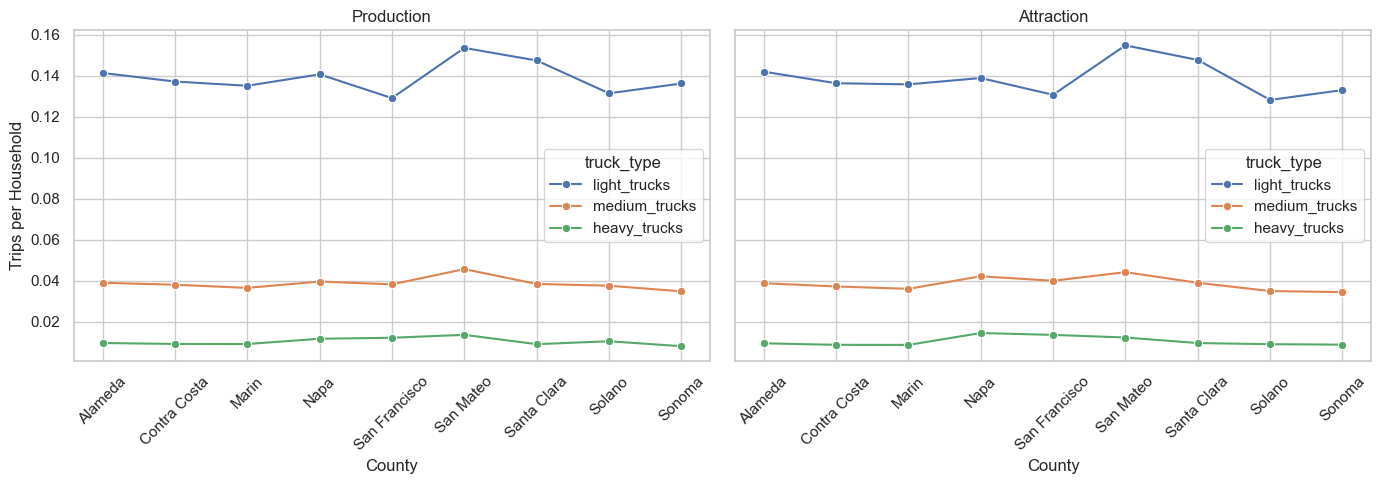

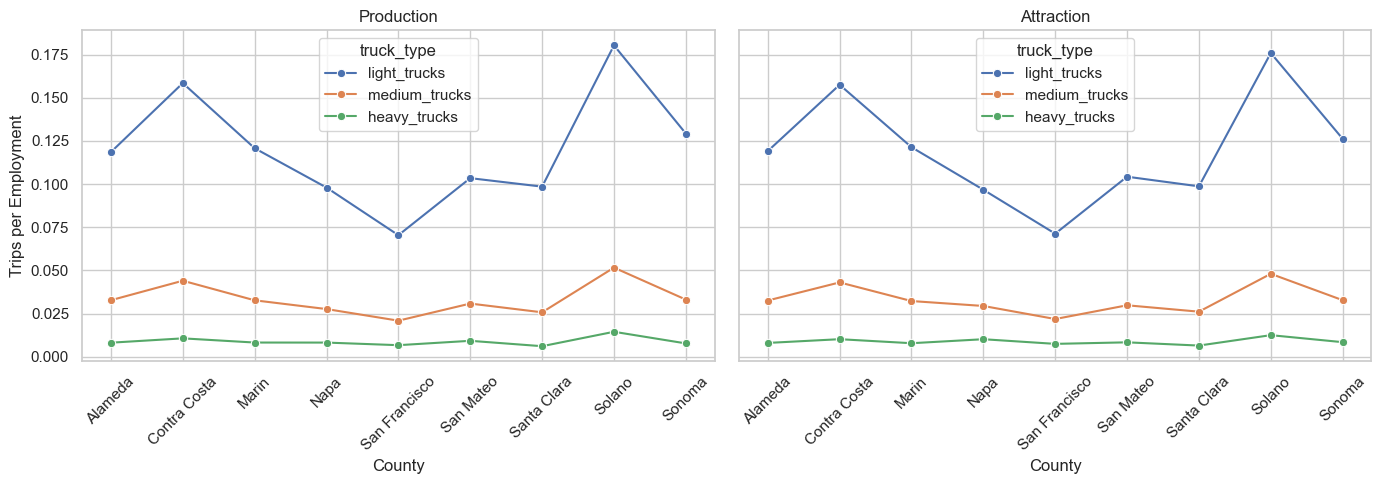

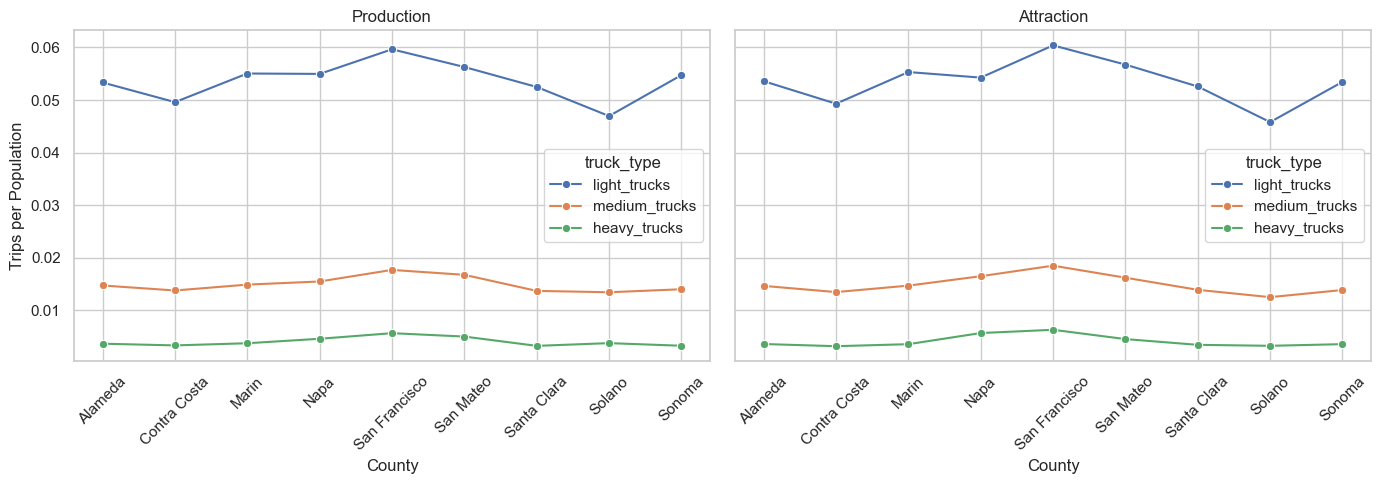

In [19]:
truck_types = ["light_trucks", "medium_trucks", "heavy_trucks"]

metrics = {
    "TOTHH": "Trips per Household",
    "TOTEMP": "Trips per Employment",
    "TOTPOP": "Trips per Population"
}



rates_df = build_rates_table(df, county_data, truck_types, metrics)
plot_rates(rates_df.dropna(), "Trips per Household")
plot_rates(rates_df.dropna(), "Trips per Employment")
plot_rates(rates_df.dropna(), "Trips per Population")

---
## 5 Trip Distributions

Computes **weighted histograms** of trip distance and trip time for each truck type, over both the full MTC region and the TNL subset.

In [40]:
# def plot_histograms(df, value_col, bins, title, x_label):
#     plt.figure(figsize=(8, 5))

#     all_results = []

#     for t in truck_types:
#         hist, edges = np.histogram(
#             df[value_col],
#             bins=bins,
#             weights=df[t]
#         )

#         centers = (edges[:-1] + edges[1:]) / 2
#         shares = hist / hist.sum()

#         # ---- store data ----
#         temp = pd.DataFrame({
#             "truck_type": t,
#             "bin_start": edges[:-1],
#             "bin_end": edges[1:],
#             "center": centers,
#             "trips": hist,
#             "share": shares
#         })

#         all_results.append(temp)

#         # ---- plot ----
#         plt.plot(centers, hist, marker="o", label=t)

#     results_df = pd.concat(all_results, ignore_index=True)

#     plt.xlabel(x_label)
#     plt.ylabel("Trips")
#     plt.title(title)
#     plt.legend()
#     plt.grid(True)
#     plt.savefig(outpath/ f'{title.lower().replace(" ", "_")}.png')
#     plt.show()

#     return results_df


In [41]:
def plot_histograms(df, value_col, bins, title, x_label):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    all_results = []

    for t in truck_types:
        hist, edges = np.histogram(
            df[value_col],
            bins=bins,
            weights=df[t]
        )

        centers = (edges[:-1] + edges[1:]) / 2
        shares = hist / hist.sum()

        # ---- store data ----
        temp = pd.DataFrame({
            "truck_type": t,
            "bin_start": edges[:-1],
            "bin_end": edges[1:],
            "center": centers,
            "trips": hist,
            "share": shares
        })
        all_results.append(temp)

        # ---- raw histogram plot ----
        axes[0].plot(centers, hist, marker="o", label=t)

        # ---- normalized (shares) plot ----
        axes[1].plot(centers, shares, marker="o", label=t)

    results_df = pd.concat(all_results, ignore_index=True)

    # ---- formatting ----
    axes[0].set_title(f"{title} (Trips)")
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel("Trips")
    axes[0].grid(True)

    axes[1].set_title(f"{title} (Share)")
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel("Share")
    axes[1].grid(True)

    axes[0].legend()
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(outpath / f'{title.lower().replace(" ", "_")}.png')
    plt.show()

    return results_df

In [42]:
county_trips = df[
    df["origin_county"].isin(CONFIG["mtc_counties"]) & 
    df["destination_county"].isin(CONFIG["mtc_counties"])
    ]


tnls = list(CONFIG["tnl_indices"].values())
tnl_trips = df[
    df["origin_county"].isin(tnls) 
    ].dropna()
    

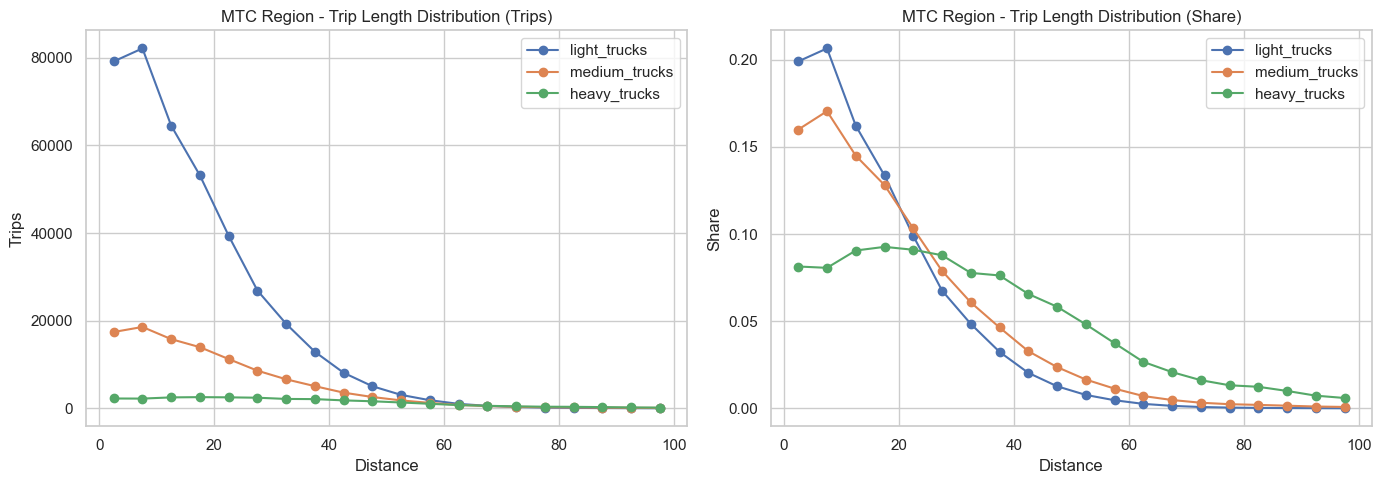

In [43]:
bins_dist = np.linspace(0, 100, 21)
dist_data_mtc = plot_histograms(county_trips, "dist_comp", bins_dist,
                           "MTC Region - Trip Length Distribution", "Distance")
dist_data_mtc.to_csv(outpath / "mtc_region_trip_length_distribution.csv")

C:\Users\USJC173858\AppData\Local\Temp\ipykernel_8556\3207264020.py:14: RuntimeWarning: invalid value encountered in divide
  shares = hist / hist.sum()


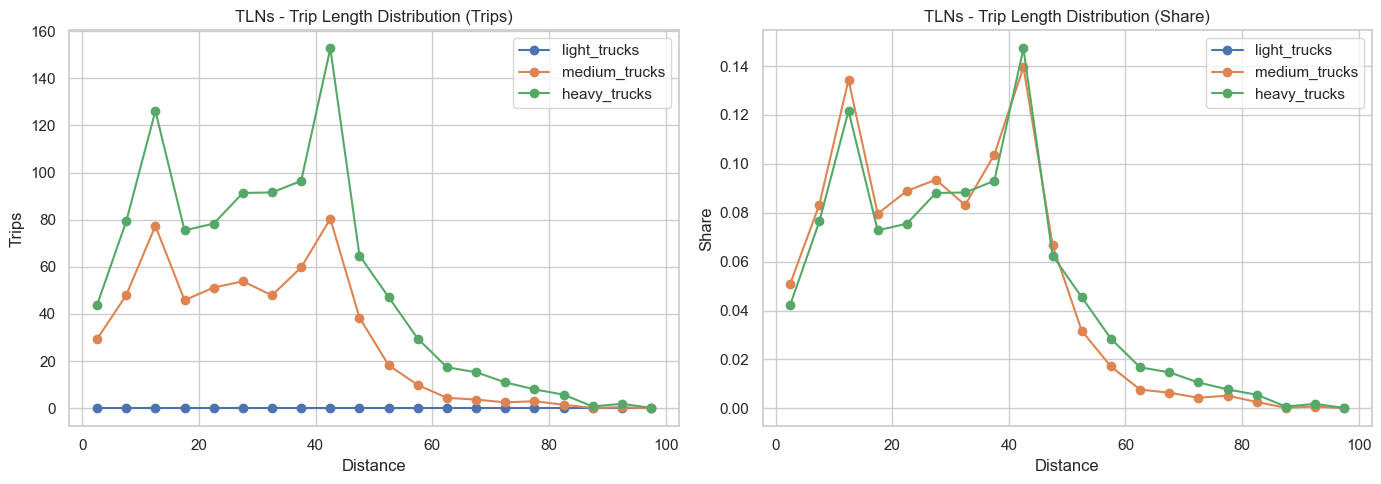

In [44]:
dist_data_tln = plot_histograms(tnl_trips, "dist_comp", bins_dist,
                           "TLNs - Trip Length Distribution", "Distance")
dist_data_tln.to_csv(outpath / "tln_trip_length_distribution.csv")

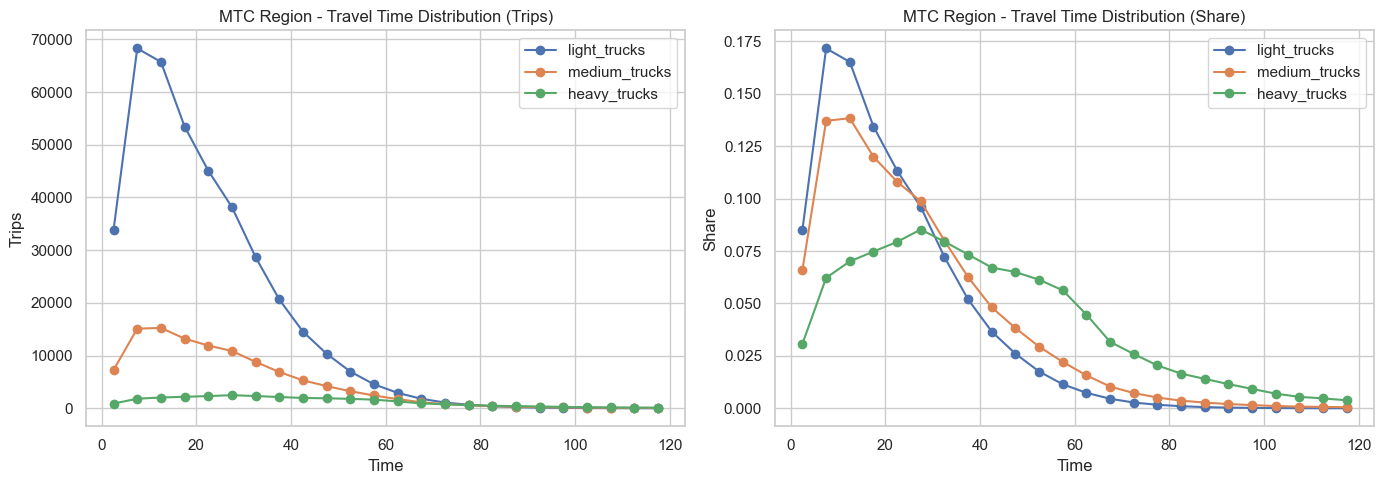

In [45]:
bins_time = np.linspace(0, 120, 25)
time_data_mtc = plot_histograms(df, "time_comp", bins_time,
                           "MTC Region - Travel Time Distribution", "Time")
dist_data_mtc.to_csv(outpath / "mtc_region_travel_time_distribution.csv")

C:\Users\USJC173858\AppData\Local\Temp\ipykernel_8556\3207264020.py:14: RuntimeWarning: invalid value encountered in divide
  shares = hist / hist.sum()


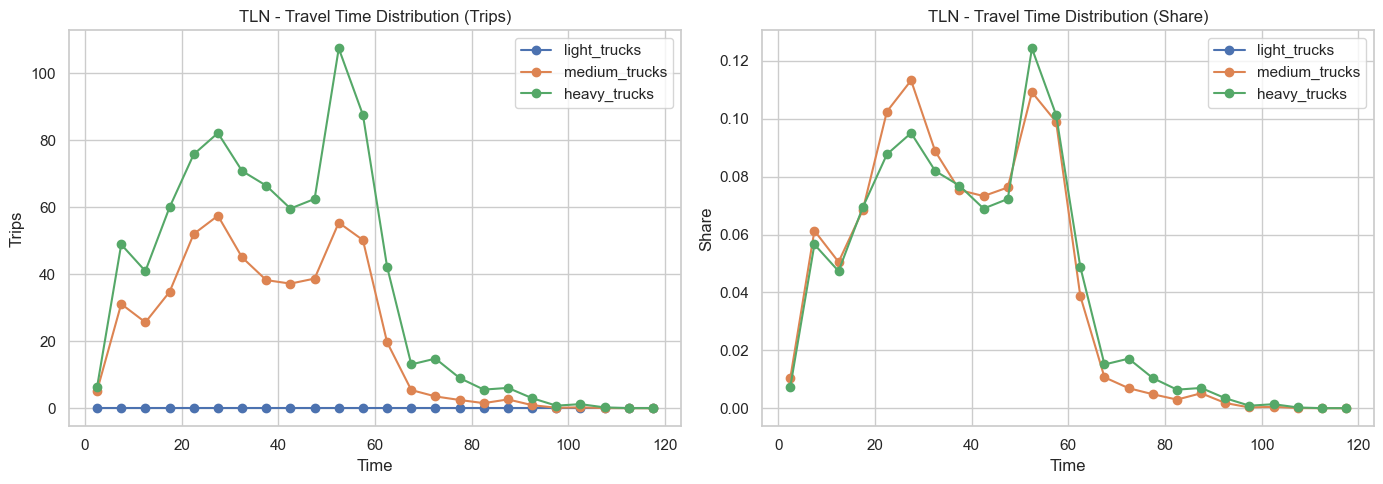

In [46]:
time_data_tln = plot_histograms(tnl_trips, "time_comp", bins_time,
                           "TLN - Travel Time Distribution", "Time")
dist_data_mtc.to_csv(outpath / "tln_travel_time_distribution.csv")